# Purpose:
- Calculate coding score across sessions
- Using no pupil GLM (v00), Thyme, natural images sessions

In [2]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
from comb.behavior_ophys_dataset import BehaviorOphysDataset, BehaviorMultiplaneOphysDataset
from comb.behavior_session_dataset import BehaviorSessionDataset
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json
from tqdm import tqdm
from matplotlib import pyplot as plt
from tqdm import tqdm

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils
import load_data
import design_matrix_tools as dmtools
import kernel_tools as ktools

In [3]:
def calculate_coding_score(var_explained_xr, models=None):
    model_labels = var_explained_xr.model
    if models is None:
        models = [m for m in model_labels if 
                  m != 'Full' and
                  not m.startswith('single-')]
    assert np.all([m in model_labels for m in models])
    assert 'Full' in model_labels
    return var_explained_xr.sel(model='Full') - var_explained_xr.sel(model=models)

In [4]:
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'


In [5]:
session_names = [rp.split('/')[-1] for rp in raw_paths]
abbr_session_names = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'abbr_session_name': abbr_session_names,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('abbr_session_name', drop=True, inplace=True)

In [6]:
session_info_df

,session_name,session_ind,session_type
abbr_session_name,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [7]:
# Loading ROICat results
roicat_dir = Path('/root/capsule/data/multiplane-ophys_ROICat_736963_natural_images_250118')
roicat_folder_names = np.arange(8)
roicat_df_list = []
for folder_names in roicat_folder_names:
    roicat_fp = roicat_dir / f'{folder_names}/ROICaT.tracking.results.csv'
    roicat_df = pd.read_csv(roicat_fp)
    roicat_df['session_key'] = roicat_df['session_name'].apply(lambda x: '_'.join(x.split('_')[1:3]))
    roicat_df['roi_name'] = roicat_df.apply(lambda x: '_'.join(
        [x.session_key, x.fov_name, f'{x.roi_session_index:04}']), axis=1)
    roicat_df['session_ind'] = roicat_df.session_key.map(lambda x: session_info_df.loc[x, 'session_ind'])
    roicat_df['unique_cell_name'] = roicat_df.apply(lambda x: x.fov_name + f'_{x.ucid:04}', axis=1)
    roicat_df_list.append(roicat_df)
roicat_df = pd.concat(roicat_df_list)

In [9]:
images_coding_score_list = []
session_names = []
session_inds = np.arange(11)

for session_ind in tqdm(range(11)):
    session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
    session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
    session_names.append(session_ind)
    glm_path = Path(glm_dir) / f'glm_results_v00_{session_name}_events.npy'
    glm_results = np.load(glm_path, allow_pickle=True).item()
    images_coding_score_xr = calculate_coding_score(
        glm_results['var_ratio_mean_model'],
        models=['all-images']).expand_dims(
            session_key=[session_key]
        )
    

    matched_unique_cell_name = []
    session_roi_cat_df = roicat_df.query(f'session_ind=={session_ind}')
    matched_df = session_roi_cat_df.query('matched==True')
    matched_roi_id = ['_'.join(rn.split('_')[2:]) for rn in matched_df.roi_name.values]
    
    zero_activity_cell_roi_ids = list(set(matched_roi_id) - set(images_coding_score_xr.cell_roi_id.values))
    # add zero values to images_coding_score_xr
    zero_xr = xr.DataArray(np.zeros(len(zero_activity_cell_roi_ids)), 
                        coords=[zero_activity_cell_roi_ids], 
                        dims=['cell_roi_id'])
    images_coding_score_xr = xr.concat([images_coding_score_xr, zero_xr], dim='cell_roi_id')
    
    images_coding_score_xr = images_coding_score_xr.sel(cell_roi_id=matched_roi_id)
    
    unique_cell_names = []
    for cell_roi_id in images_coding_score_xr.cell_roi_id.values:
        roi_name = f'{session_key}_{cell_roi_id}'
        unique_cell_names.append(session_roi_cat_df.query(f'roi_name=="{roi_name}"').unique_cell_name.values[0])
    
    images_coding_score_xr = images_coding_score_xr.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
    images_coding_score_xr = images_coding_score_xr.swap_dims({"cell_roi_id": "unique_cell_name"})
    
    images_coding_score_list.append(images_coding_score_xr)



  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:21<00:00,  1.93s/it]


In [10]:
images_coding_score_sessions = xr.concat(images_coding_score_list, dim='session_key')

In [11]:
num_matched_sessions_threshold = 11
num_matching_series = roicat_df.query('matched').groupby('unique_cell_name').size()
all_matched_unique_cell_names = num_matching_series.index.values[np.where(num_matching_series>=num_matched_sessions_threshold)[0]]
all_matched_images_coding_score = images_coding_score_sessions.sel(unique_cell_name=all_matched_unique_cell_names)

In [12]:
np.array_equal(np.sort(all_matched_images_coding_score.session_key.values), 
               all_matched_images_coding_score.session_key.values)

True

In [13]:
novelty_sorted_inds = np.argsort(-all_matched_images_coding_score.isel(session_key=0), axis=0).squeeze()

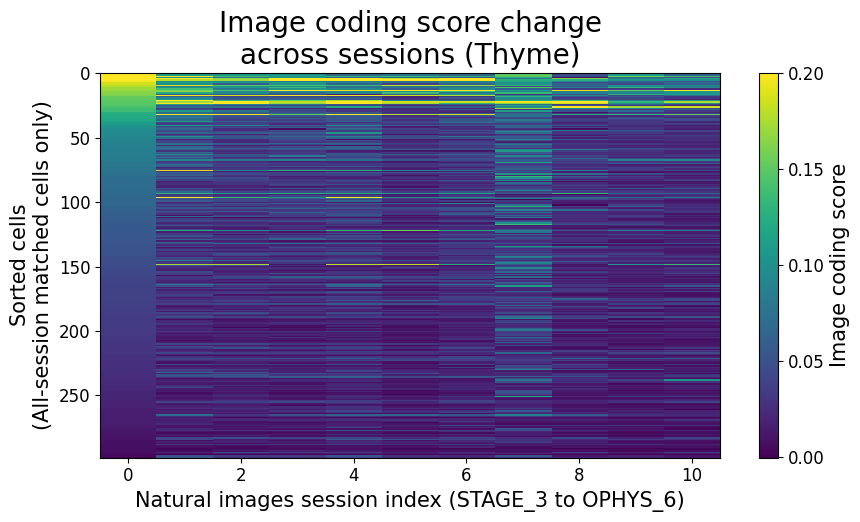

In [15]:
fig, ax = plt.subplots(figsize=(10,5))
values = all_matched_images_coding_score.values.squeeze().T
sorted_values = values[novelty_sorted_inds,:]
im = ax.imshow(sorted_values,
          aspect='auto',
          interpolation='none',
            vmax=0.2)
cbar = plt.colorbar(im)
cbar.set_ticks([0, 0.05, 0.1, 0.15, 0.2])
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Image coding score', fontsize=15)
ax.set_xlabel('Natural images session index (STAGE_3 to OPHYS_6)', fontsize=15)
ax.set_ylabel('Sorted cells\n(All-session matched cells only)', fontsize=15)
ax.set_title('Image coding score change\nacross sessions (Thyme)', fontsize=20)
ax.tick_params(axis='both', labelsize=12)